# 🎓 Students Performance in Exams — Analisis Lengkap
Dataset: [Kaggle - Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

**Outline:**
1. Setup & Load Data
2. Exploratory Data Analysis (EDA)
3. Visualisasi Distribusi Nilai
4. Analisis Faktor
5. Prediksi Nilai dengan Machine Learning

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F8F9FA'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#6366F1', '#0EA5E9', '#10B981', '#F59F00', '#EF4444']
SCORE_COLORS = {'math score': '#6366F1', 'reading score': '#0EA5E9', 'writing score': '#10B981'}
sns.set_palette(COLORS)

print('✅ Library berhasil di-import')

✅ Library berhasil di-import


In [2]:
# Load dataset — pastikan file ada di direktori yang sama
df = pd.read_csv('StudentsPerformance.csv')

# Rename kolom agar lebih mudah diakses
df.columns = df.columns.str.strip()

print(f'✅ Dataset berhasil dimuat: {df.shape[0]} baris × {df.shape[1]} kolom')
df.head(10)

✅ Dataset berhasil dimuat: 1000 baris × 8 kolom


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


## 2. Exploratory Data Analysis (EDA)

In [3]:
print('=' * 55)
print('📋 INFO DATASET')
print('=' * 55)
df.info()

📋 INFO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [4]:
print('=' * 55)
print('📐 STATISTIK DESKRIPTIF (Nilai Numerik)')
print('=' * 55)
df[['math score', 'reading score', 'writing score']].describe().round(2)

📐 STATISTIK DESKRIPTIF (Nilai Numerik)


,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [5]:
print('=' * 55)
print('❓ MISSING VALUES')
print('=' * 55)
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()} → Dataset BERSIH ✅')

❓ MISSING VALUES
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Total missing: 0 → Dataset BERSIH ✅


In [6]:
print('=' * 55)
print('📊 VALUE COUNTS — Kolom Kategorikal')
print('=' * 55)
cat_cols = ['gender', 'race/ethnicity', 'parental level of education',
            'lunch', 'test preparation course']
for col in cat_cols:
    print(f'\n🔹 {col.upper()}')
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    result = pd.DataFrame({'Count': vc, 'Pct (%)': pct.round(1)})
    print(result)

📊 VALUE COUNTS — Kolom Kategorikal

🔹 GENDER
        Count  Pct (%)
gender                
female    518     51.8
male      482     48.2

🔹 RACE/ETHNICITY
                Count  Pct (%)
race/ethnicity                
group C           319     31.9
group D           262     26.2
group B           190     19.0
group E           140     14.0
group A            89      8.9

🔹 PARENTAL LEVEL OF EDUCATION
                             Count  Pct (%)
parental level of education                
some college                   226     22.6
associate's degree             222     22.2
high school                    196     19.6
some high school               179     17.9
bachelor's degree              118     11.8
master's degree                 59      5.9

🔹 LUNCH
              Count  Pct (%)
lunch                       
standard        645     64.5
free/reduced    355     35.5

🔹 TEST PREPARATION COURSE
                         Count  Pct (%)
test preparation course                
none         

🔗 KORELASI ANTAR NILAI


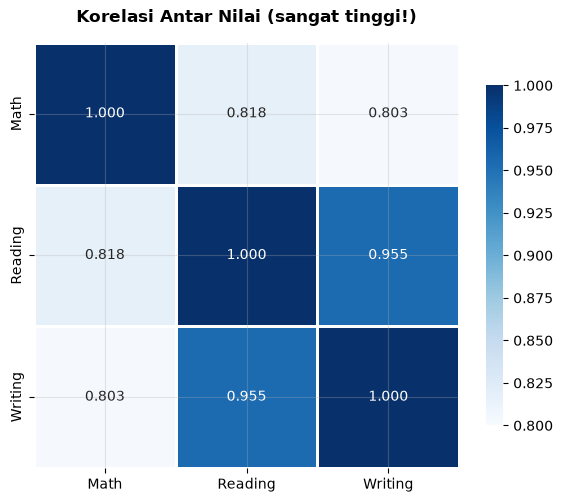


Math–Reading  : 0.818
Math–Writing  : 0.803
Reading–Writing: 0.955


In [7]:
# Korelasi antar nilai
print('=' * 55)
print('🔗 KORELASI ANTAR NILAI')
print('=' * 55)
corr = df[['math score', 'reading score', 'writing score']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            vmin=0.8, vmax=1.0, square=True, linewidths=2,
            xticklabels=['Math', 'Reading', 'Writing'],
            yticklabels=['Math', 'Reading', 'Writing'],
            cbar_kws={'shrink': 0.8})
ax.set_title('Korelasi Antar Nilai (sangat tinggi!)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f"\nMath–Reading  : {corr.loc['math score','reading score']:.3f}")
print(f"Math–Writing  : {corr.loc['math score','writing score']:.3f}")
print(f"Reading–Writing: {corr.loc['reading score','writing score']:.3f}")

## 3. Visualisasi Distribusi Nilai

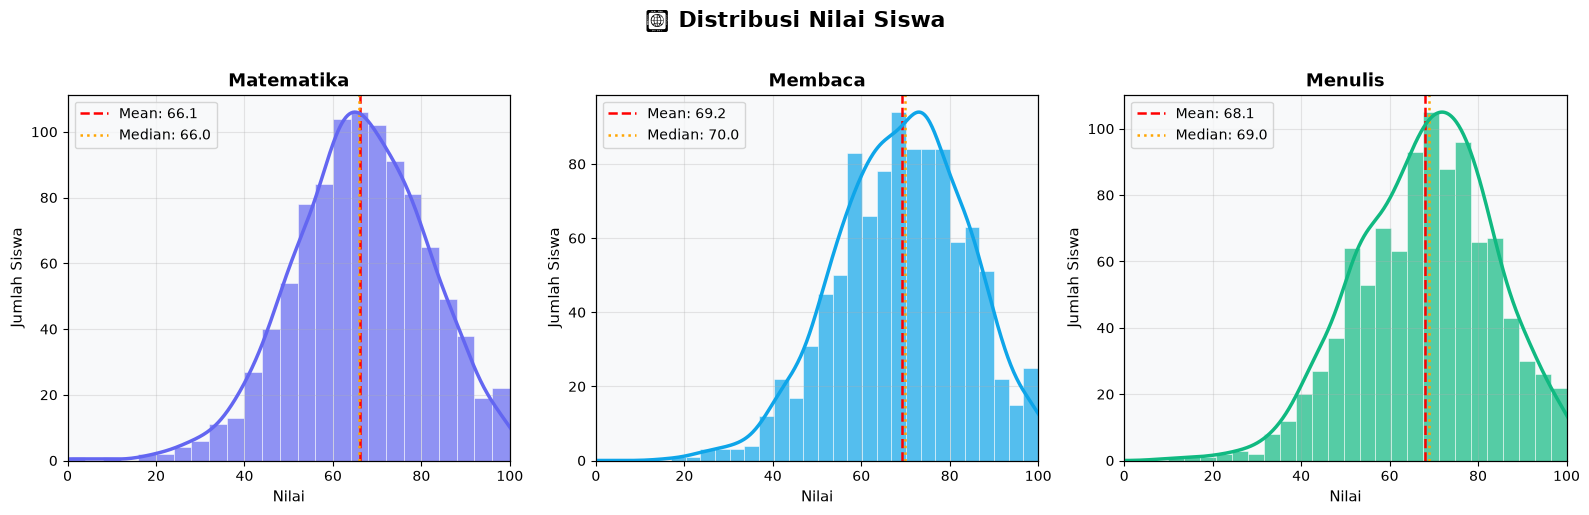

In [8]:
# Histogram + KDE untuk ketiga nilai
score_cols = ['math score', 'reading score', 'writing score']
labels = ['Matematika', 'Membaca', 'Menulis']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('📊 Distribusi Nilai Siswa', fontsize=16, fontweight='bold', y=1.02)

for ax, col, label, color in zip(axes, score_cols, labels, COLORS):
    ax.hist(df[col], bins=25, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax2 = ax.twinx()
    df[col].plot.kde(ax=ax2, color=color, linewidth=2.5)
    ax2.set_ylabel('')
    ax2.set_yticks([])
    ax2.set_ylim(bottom=0)

    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.8, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='orange', linestyle=':', linewidth=1.8, label=f'Median: {median_val:.1f}')

    ax.set_title(f'{label}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Nilai', fontsize=11)
    ax.set_ylabel('Jumlah Siswa', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

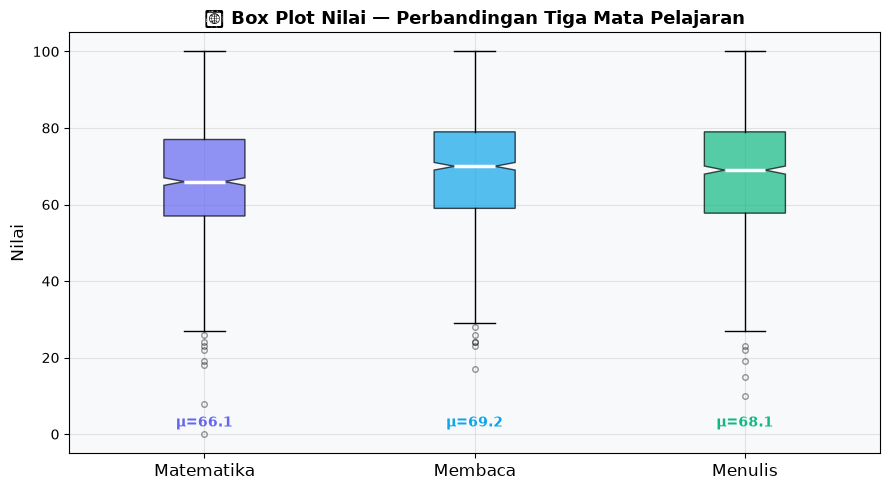

In [9]:
# Box Plot — semua nilai
fig, ax = plt.subplots(figsize=(9, 5))

data_to_plot = [df['math score'], df['reading score'], df['writing score']]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=True,
                medianprops=dict(color='white', linewidth=2.5),
                flierprops=dict(marker='o', markersize=4, alpha=0.4))

for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(['Matematika', 'Membaca', 'Menulis'], fontsize=12)
ax.set_ylabel('Nilai', fontsize=12)
ax.set_title('📦 Box Plot Nilai — Perbandingan Tiga Mata Pelajaran',
             fontweight='bold', fontsize=13)
for i, (col, label) in enumerate(zip(score_cols, labels)):
    ax.text(i+1, 2, f"μ={df[col].mean():.1f}", ha='center', fontsize=10,
            color=COLORS[i], fontweight='bold')
plt.tight_layout()
plt.show()

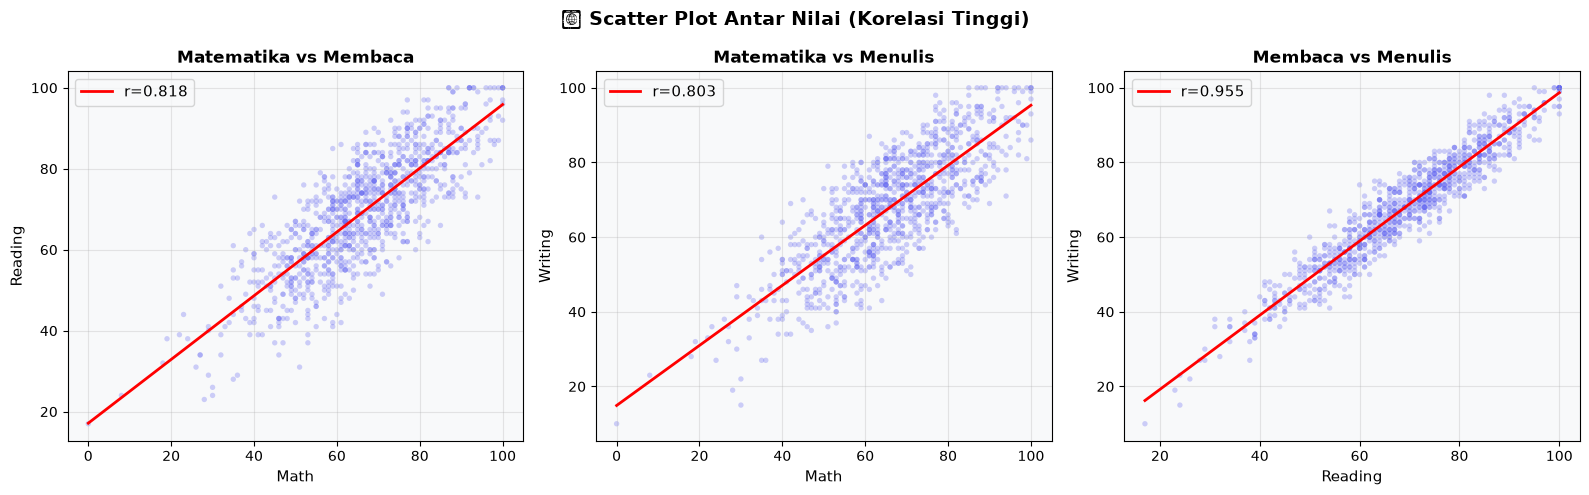

In [10]:
# Scatter plot antar nilai
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('🔗 Scatter Plot Antar Nilai (Korelasi Tinggi)', fontsize=14, fontweight='bold')

pairs = [
    ('math score', 'reading score', 'Matematika vs Membaca'),
    ('math score', 'writing score', 'Matematika vs Menulis'),
    ('reading score', 'writing score', 'Membaca vs Menulis'),
]

for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(df[x], df[y], alpha=0.3, color=COLORS[0], s=15, edgecolors='none')
    m, b = np.polyfit(df[x], df[y], 1)
    xline = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(xline, m*xline+b, color='red', linewidth=2, label=f'r={df[[x,y]].corr().iloc[0,1]:.3f}')
    ax.set_xlabel(x.replace(' score','').capitalize(), fontsize=11)
    ax.set_ylabel(y.replace(' score','').capitalize(), fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 4. Analisis Faktor

In [11]:
def plot_factor(df, group_col, title, figsize=(10, 4), ylim=(40, 85), sort_by='math score'):
    """Plot rata-rata nilai berdasarkan kelompok tertentu"""
    grp = df.groupby(group_col)[score_cols].mean().sort_values(sort_by)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Bar chart
    x = np.arange(len(grp))
    w = 0.28
    ax = axes[0]
    for i, (col, label, color) in enumerate(zip(score_cols, labels, COLORS)):
        bars = ax.bar(x + i*w, grp[col], width=w, label=label, color=color,
                      alpha=0.85, edgecolor='white')
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                    f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x + w)
    ax.set_xticklabels(grp.index, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(ylim)
    ax.set_ylabel('Rata-rata Nilai', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=12)

    # Heatmap
    ax2 = axes[1]
    heat_data = grp[score_cols]
    heat_data.columns = ['Math', 'Reading', 'Writing']
    sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='Blues',
                ax=ax2, cbar=True, linewidths=1,
                vmin=grp.values.min()-2, vmax=grp.values.max()+2)
    ax2.set_title('Heatmap Nilai per Kelompok', fontweight='bold', fontsize=12)
    ax2.set_ylabel('')

    plt.tight_layout()
    plt.show()
    return grp

👥 FAKTOR 1: GENDER


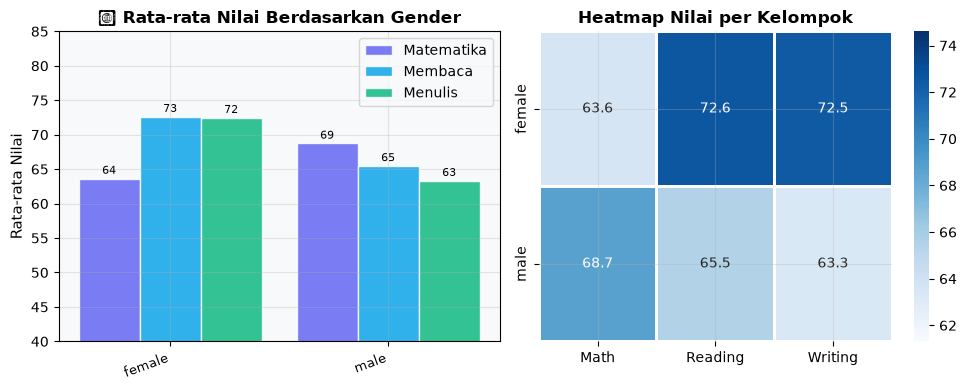

        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31


In [12]:
print('👥 FAKTOR 1: GENDER')
grp_gender = plot_factor(df, 'gender', '👥 Rata-rata Nilai Berdasarkan Gender', figsize=(10,4))
print(grp_gender.round(2))

🌍 FAKTOR 2: RAS/ETNIS


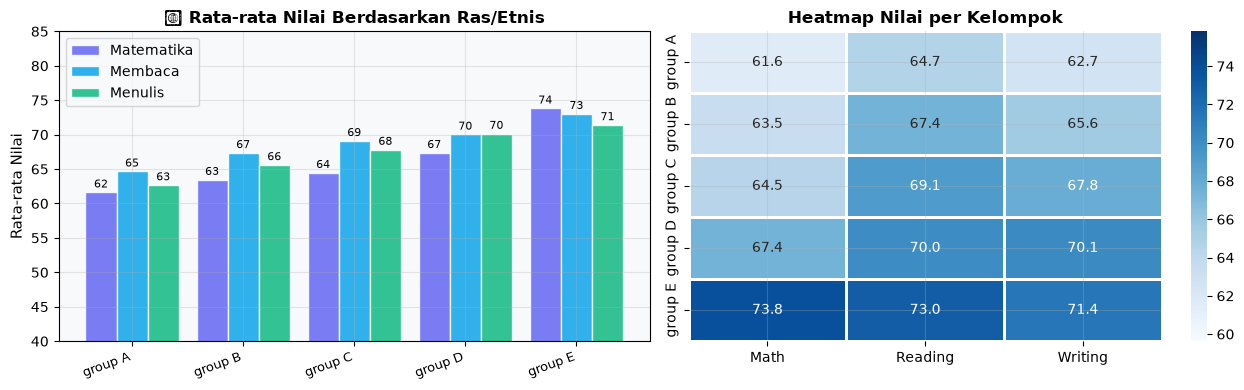

                math score  reading score  writing score
race/ethnicity                                          
group A              61.63          64.67          62.67
group B              63.45          67.35          65.60
group C              64.46          69.10          67.83
group D              67.36          70.03          70.15
group E              73.82          73.03          71.41


In [13]:
print('🌍 FAKTOR 2: RAS/ETNIS')
grp_race = plot_factor(df, 'race/ethnicity', '🌍 Rata-rata Nilai Berdasarkan Ras/Etnis', figsize=(13,4))
print(grp_race.round(2))

🎓 FAKTOR 3: PENDIDIKAN ORANG TUA


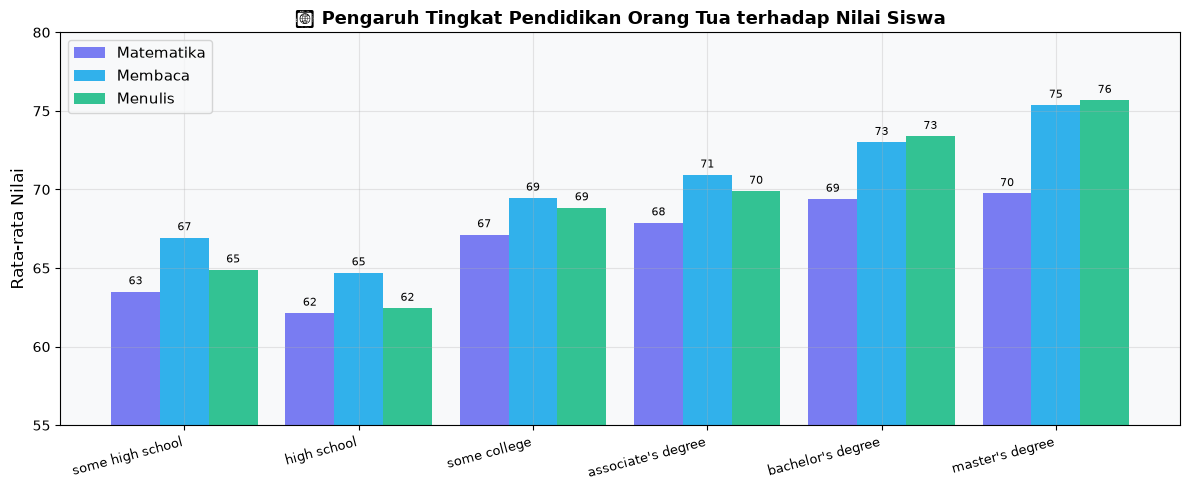

                    math score  reading score  writing score
edu_ordered                                                 
some high school         63.50          66.94          64.89
high school              62.14          64.70          62.45
some college             67.13          69.46          68.84
associate's degree       67.88          70.93          69.90
bachelor's degree        69.39          73.00          73.38
master's degree          69.75          75.37          75.68


In [14]:
print('🎓 FAKTOR 3: PENDIDIKAN ORANG TUA')
# Urutkan berdasarkan level pendidikan
edu_order = ['some high school', 'high school', 'some college',
             "associate's degree", "bachelor's degree", "master's degree"]
df['edu_ordered'] = pd.Categorical(df['parental level of education'],
                                    categories=edu_order, ordered=True)
grp_edu = df.groupby('edu_ordered')[score_cols].mean()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(grp_edu))
w = 0.28
for i, (col, label, color) in enumerate(zip(score_cols, labels, COLORS)):
    bars = ax.bar(x+i*w, grp_edu[col], width=w, label=label, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x+w)
ax.set_xticklabels(grp_edu.index, rotation=15, ha='right', fontsize=9)
ax.set_ylim(55, 80)
ax.set_ylabel('Rata-rata Nilai', fontsize=12)
ax.set_title('🎓 Pengaruh Tingkat Pendidikan Orang Tua terhadap Nilai Siswa',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()
print(grp_edu.round(2))

🍽️ FAKTOR 4: JENIS MAKAN SIANG


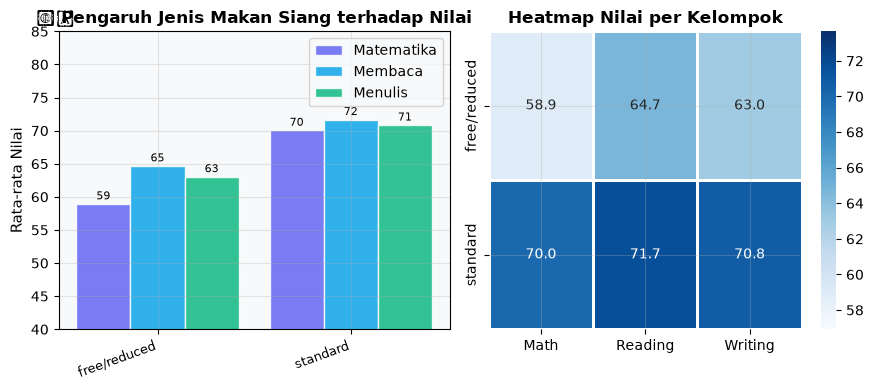


Selisih nilai (standard - free/reduced):
math score       11.11
reading score     7.00
writing score     7.80
dtype: float64


In [15]:
print('🍽️ FAKTOR 4: JENIS MAKAN SIANG')
grp_lunch = plot_factor(df, 'lunch', '🍽️ Pengaruh Jenis Makan Siang terhadap Nilai', figsize=(9,4))
diff = grp_lunch.loc['standard'] - grp_lunch.loc['free/reduced']
print(f'\nSelisih nilai (standard - free/reduced):')
print(diff.round(2))

📝 FAKTOR 5: TEST PREPARATION COURSE


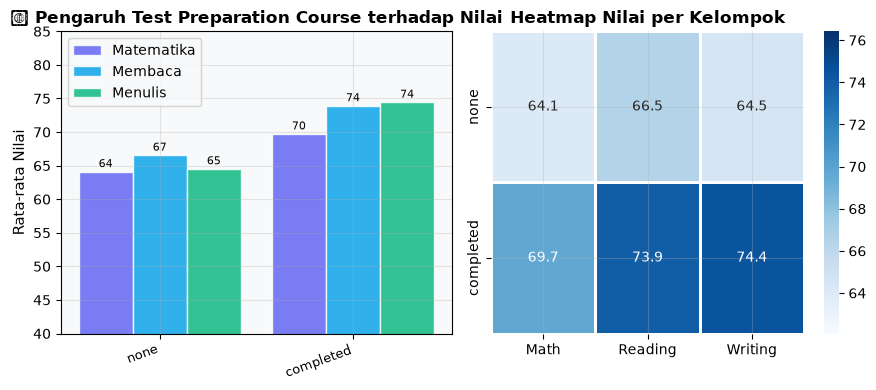


Selisih nilai (completed - none):
math score       5.62
reading score    7.36
writing score    9.91
dtype: float64


In [16]:
print('📝 FAKTOR 5: TEST PREPARATION COURSE')
grp_prep = plot_factor(df, 'test preparation course',
                       '📝 Pengaruh Test Preparation Course terhadap Nilai', figsize=(9,4))
diff_prep = grp_prep.loc['completed'] - grp_prep.loc['none']
print(f'\nSelisih nilai (completed - none):')
print(diff_prep.round(2))


📊 EFFECT SIZE — Seberapa besar pengaruh tiap faktor?
(diukur dari range rata-rata antar kelompok)



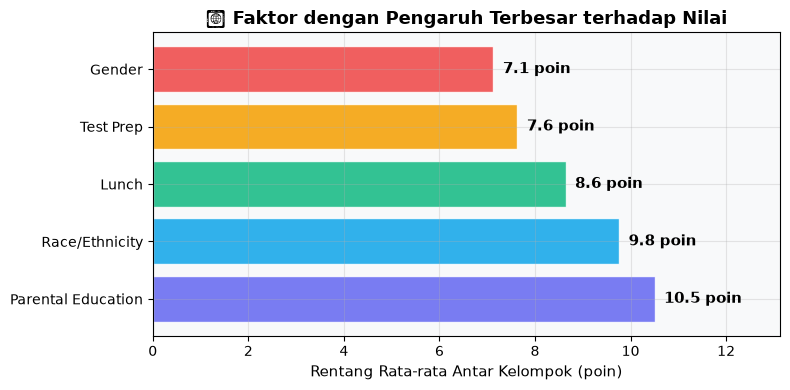

                    Avg Effect (poin)
Parental Education              10.50
Race/Ethnicity                   9.76
Lunch                            8.64
Test Prep                        7.63
Gender                           7.13


In [17]:
# Ringkasan pengaruh semua faktor (effect size)
print('\n📊 EFFECT SIZE — Seberapa besar pengaruh tiap faktor?')
print('(diukur dari range rata-rata antar kelompok)\n')

effects = {}
for col_name, group_col in [
    ('Gender', 'gender'),
    ('Race/Ethnicity', 'race/ethnicity'),
    ('Parental Education', 'parental level of education'),
    ('Lunch', 'lunch'),
    ('Test Prep', 'test preparation course'),
]:
    grp = df.groupby(group_col)[score_cols].mean()
    effects[col_name] = (grp.max() - grp.min()).mean()

effect_df = pd.DataFrame.from_dict(effects, orient='index', columns=['Avg Effect (poin)'])
effect_df = effect_df.sort_values('Avg Effect (poin)', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(effect_df.index, effect_df['Avg Effect (poin)'],
               color=COLORS[:len(effect_df)], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, effect_df['Avg Effect (poin)']):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2, f'{val:.1f} poin',
            va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Rentang Rata-rata Antar Kelompok (poin)', fontsize=11)
ax.set_title('🏆 Faktor dengan Pengaruh Terbesar terhadap Nilai', fontweight='bold', fontsize=13)
ax.set_xlim(0, effect_df.values.max() * 1.25)
plt.tight_layout()
plt.show()

print(effect_df.round(2))

## 5. Machine Learning — Prediksi Nilai

In [18]:
# ── Preprocessing ──
df_ml = df.copy()

# Encode fitur kategorikal
cat_features = ['gender', 'race/ethnicity', 'parental level of education',
                'lunch', 'test preparation course']

df_encoded = pd.get_dummies(df_ml[cat_features], drop_first=False)

X = df_encoded.astype(int)
y = df_ml[score_cols]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale untuk Linear Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size : {X_train.shape[0]} sampel')
print(f'Test size  : {X_test.shape[0]} sampel')
print(f'Features   : {X.shape[1]} fitur (setelah one-hot encoding)')
print(f'\nFitur yang digunakan:')
for col in X.columns:
    print(f'  - {col}')

Train size : 800 sampel
Test size  : 200 sampel
Features   : 17 fitur (setelah one-hot encoding)

Fitur yang digunakan:
  - gender_female
  - gender_male
  - race/ethnicity_group A
  - race/ethnicity_group B
  - race/ethnicity_group C
  - race/ethnicity_group D
  - race/ethnicity_group E
  - parental level of education_associate's degree
  - parental level of education_bachelor's degree
  - parental level of education_high school
  - parental level of education_master's degree
  - parental level of education_some college
  - parental level of education_some high school
  - lunch_free/reduced
  - lunch_standard
  - test preparation course_completed
  - test preparation course_none


In [19]:
# ── Train 3 Model ──
models = {
    'Linear Regression': MultiOutputRegressor(LinearRegression()),
    'Random Forest': MultiOutputRegressor(RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)),
    'Gradient Boosting': MultiOutputRegressor(GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)),
}

results = {}
print('🏋️ Training Model...\n')
for name, model in models.items():
    X_tr = X_train_sc if name == 'Linear Regression' else X_train
    X_te = X_test_sc  if name == 'Linear Regression' else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    r2s, rmses, maes = [], [], []
    for i, col in enumerate(score_cols):
        r2   = r2_score(y_test[col], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_test[col], y_pred[:, i]))
        mae  = mean_absolute_error(y_test[col], y_pred[:, i])
        r2s.append(r2); rmses.append(rmse); maes.append(mae)

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'avg_r2':   np.mean(r2s),
        'avg_rmse': np.mean(rmses),
        'avg_mae':  np.mean(maes),
        'r2_per_target':   dict(zip(['Math','Read','Write'], r2s)),
        'rmse_per_target': dict(zip(['Math','Read','Write'], rmses)),
    }
    print(f"✅ {name:25s}  R²={np.mean(r2s):.4f}  RMSE={np.mean(rmses):.2f}  MAE={np.mean(maes):.2f}")

print('\n✅ Training selesai!')

🏋️ Training Model...

✅ Linear Regression          R²=0.1997  RMSE=13.76  MAE=10.76
✅ Random Forest              R²=0.0762  RMSE=14.78  MAE=11.45
✅ Gradient Boosting          R²=0.0614  RMSE=14.90  MAE=11.53

✅ Training selesai!


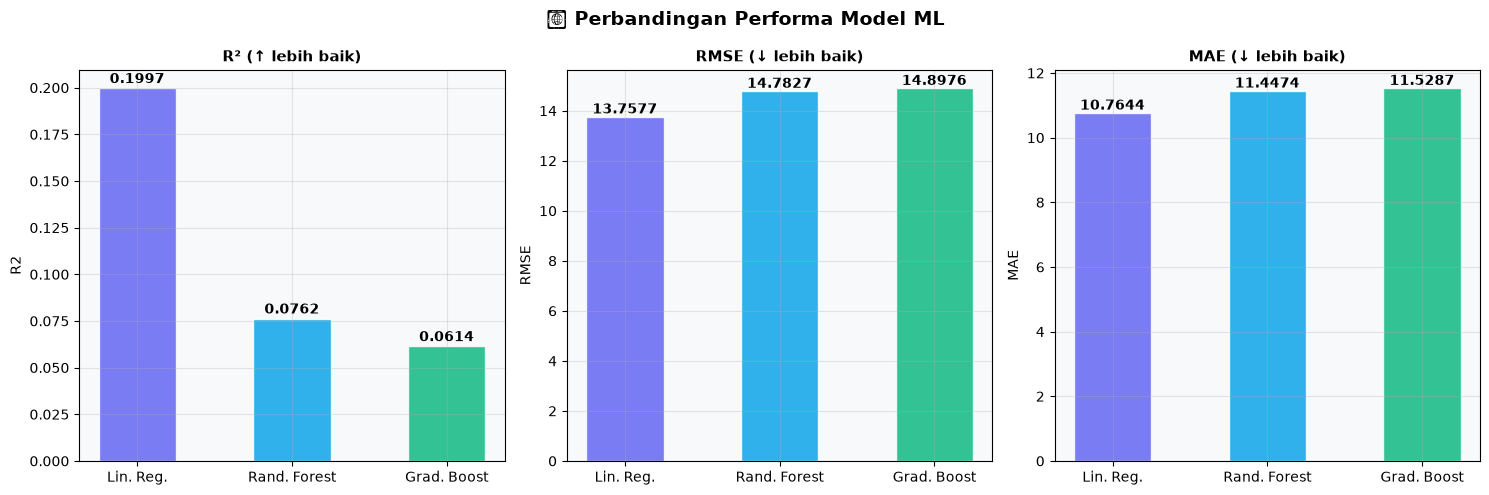


🏆 Model terbaik: Linear Regression
   R²   = 0.1997
   RMSE = 13.76
   MAE  = 10.76


In [20]:
# ── Perbandingan Model ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('📊 Perbandingan Performa Model ML', fontsize=14, fontweight='bold')

model_names = list(results.keys())
short_names = ['Lin. Reg.', 'Rand. Forest', 'Grad. Boost']
metrics = ['avg_r2', 'avg_rmse', 'avg_mae']
metric_labels = ['R² (↑ lebih baik)', 'RMSE (↓ lebih baik)', 'MAE (↓ lebih baik)']

for ax, metric, mlabel in zip(axes, metrics, metric_labels):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(short_names, vals, color=COLORS[:3], alpha=0.85, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(mlabel, fontweight='bold', fontsize=11)
    ax.set_ylabel(metric.replace('avg_','').upper())

plt.tight_layout()
plt.show()

# Pilih model terbaik
best_name = max(results, key=lambda m: results[m]['avg_r2'])
print(f'\n🏆 Model terbaik: {best_name}')
print(f'   R²   = {results[best_name]["avg_r2"]:.4f}')
print(f'   RMSE = {results[best_name]["avg_rmse"]:.2f}')
print(f'   MAE  = {results[best_name]["avg_mae"]:.2f}')

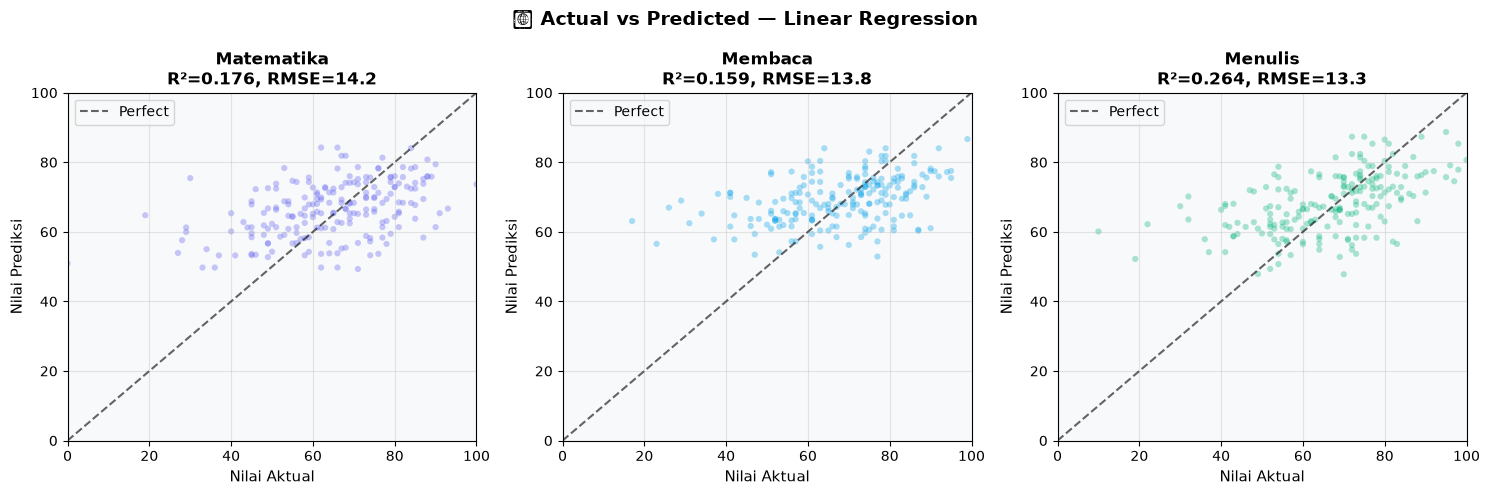

In [21]:
# ── Actual vs Predicted (Best Model) ──
best = results[best_name]
y_pred_best = best['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'🎯 Actual vs Predicted — {best_name}', fontsize=14, fontweight='bold')

for ax, col, pred_col, label, color in zip(axes, score_cols, range(3), labels, COLORS):
    actual = y_test[col].values
    pred   = y_pred_best[:, pred_col]
    r2     = r2_score(actual, pred)
    rmse   = np.sqrt(mean_squared_error(actual, pred))

    ax.scatter(actual, pred, alpha=0.35, color=color, s=20, edgecolors='none')
    lims = [0, 100]
    ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.6, label='Perfect')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Nilai Aktual', fontsize=11)
    ax.set_ylabel('Nilai Prediksi', fontsize=11)
    ax.set_title(f'{label}\nR²={r2:.3f}, RMSE={rmse:.1f}', fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

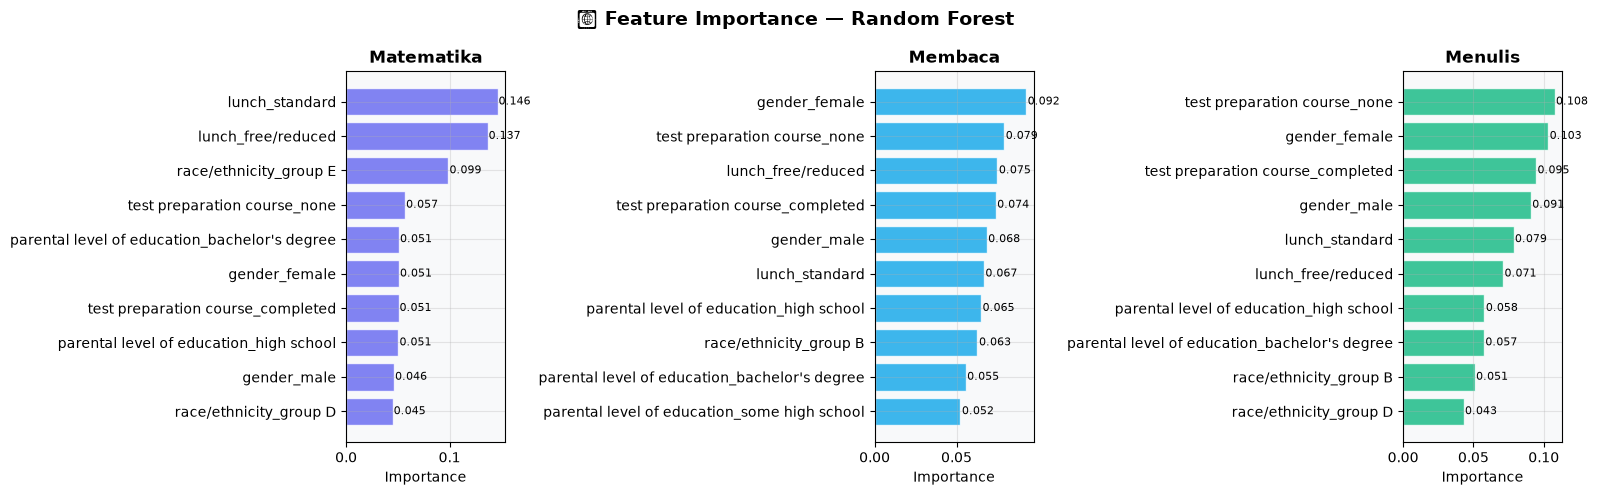

In [22]:
# ── Feature Importance (Random Forest) ──
rf_model = results['Random Forest']['model']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('🌲 Feature Importance — Random Forest', fontsize=14, fontweight='bold')

for ax, estimator, label, color in zip(axes, rf_model.estimators_, labels, COLORS):
    importances = estimator.feature_importances_
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
    # Top 10
    top = feat_imp.tail(10)
    bars = ax.barh(top.index, top.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{label}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance', fontsize=10)
    for bar, val in zip(bars, top.values):
        ax.text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.3f}',
                va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [23]:
# ── Prediksi untuk Siswa Baru ──
print('🔮 PREDIKSI NILAI UNTUK SISWA BARU')
print('=' * 50)

# Contoh profil siswa
new_students = [
    {
        'gender': 'female',
        'race/ethnicity': 'group E',
        'parental level of education': "master's degree",
        'lunch': 'standard',
        'test preparation course': 'completed',
    },
    {
        'gender': 'male',
        'race/ethnicity': 'group A',
        'parental level of education': 'some high school',
        'lunch': 'free/reduced',
        'test preparation course': 'none',
    },
    {
        'gender': 'female',
        'race/ethnicity': 'group C',
        'parental level of education': 'some college',
        'lunch': 'standard',
        'test preparation course': 'none',
    },
]

# Encode siswa baru menggunakan kolom yang sama
for i, student in enumerate(new_students):
    student_df = pd.DataFrame([student])
    student_encoded = pd.get_dummies(student_df, drop_first=False)

    # Align kolom dengan training data
    student_encoded = student_encoded.reindex(columns=X.columns, fill_value=0).astype(int)

    # Gunakan Random Forest (best model)
    X_new = student_encoded
    pred = rf_model.predict(X_new)[0]
    pred = np.clip(np.round(pred), 0, 100).astype(int)

    avg = pred.mean()
    grade = 'A (Sangat Baik)' if avg>=80 else 'B (Baik)' if avg>=70 else 'C (Cukup)' if avg>=60 else 'D (Perlu Perbaikan)'

    print(f'\n👤 Siswa {i+1}: {student["gender"].capitalize()}, {student["race/ethnicity"]}')
    print(f'   Pendidikan ortu : {student["parental level of education"]}')
    print(f'   Makan siang     : {student["lunch"]}')
    print(f'   Test prep       : {student["test preparation course"]}')
    print(f'   ─────────────────────────────────────')
    print(f'   📐 Matematika   : {pred[0]}')
    print(f'   📚 Membaca      : {pred[1]}')
    print(f'   ✍️  Menulis      : {pred[2]}')
    print(f'   📊 Rata-rata    : {avg:.1f} → {grade}')

🔮 PREDIKSI NILAI UNTUK SISWA BARU

👤 Siswa 1: Female, group E
   Pendidikan ortu : master's degree
   Makan siang     : standard
   Test prep       : completed
   ─────────────────────────────────────
   📐 Matematika   : 88
   📚 Membaca      : 90
   ✍️  Menulis      : 90
   📊 Rata-rata    : 89.3 → A (Sangat Baik)

👤 Siswa 2: Male, group A
   Pendidikan ortu : some high school
   Makan siang     : free/reduced
   Test prep       : none
   ─────────────────────────────────────
   📐 Matematika   : 61
   📚 Membaca      : 60
   ✍️  Menulis      : 54
   📊 Rata-rata    : 58.3 → D (Perlu Perbaikan)

👤 Siswa 3: Female, group C
   Pendidikan ortu : some college
   Makan siang     : standard
   Test prep       : none
   ─────────────────────────────────────
   📐 Matematika   : 66
   📚 Membaca      : 72
   ✍️  Menulis      : 73
   📊 Rata-rata    : 70.3 → B (Baik)


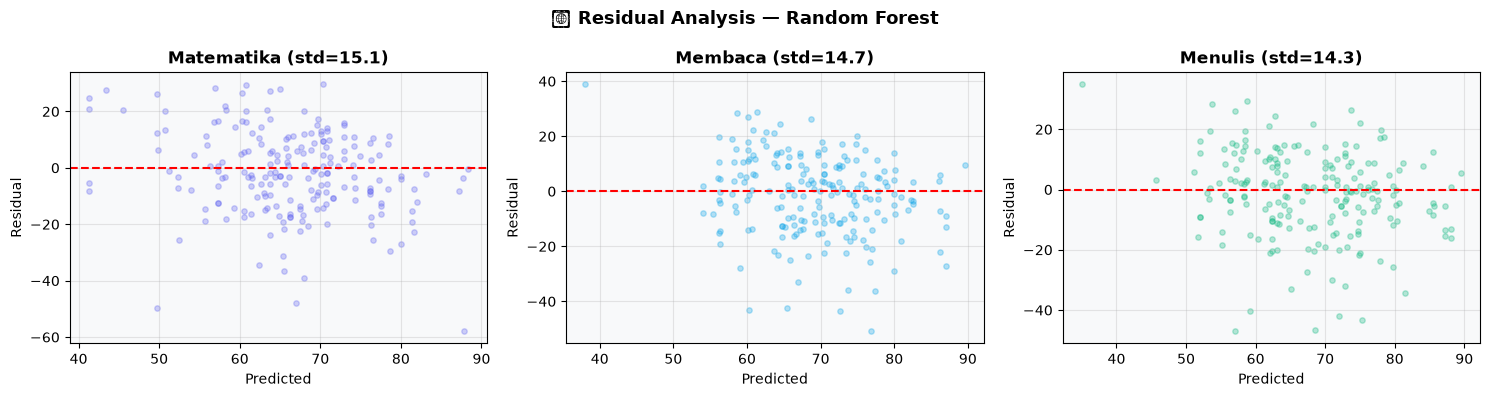

In [24]:
# ── Residual Analysis ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('📉 Residual Analysis — Random Forest', fontsize=13, fontweight='bold')

rf_pred = results['Random Forest']['y_pred']
for ax, col, pred_col, label, color in zip(axes, score_cols, range(3), labels, COLORS):
    residuals = y_test[col].values - rf_pred[:, pred_col]
    ax.scatter(rf_pred[:, pred_col], residuals, alpha=0.3, color=color, s=15)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Residual', fontsize=10)
    ax.set_title(f'{label} (std={residuals.std():.1f})', fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
# ── Ringkasan Akhir ──
print('=' * 60)
print('📋 RINGKASAN TEMUAN')
print('=' * 60)

print("""
📊 EDA:
  • Dataset: 1000 siswa, 8 kolom, 0 missing values
  • Komposisi gender hampir seimbang (female 52%, male 48%)
  • Group C adalah ras/etnis terbesar (32%)

📈 Distribusi Nilai:
  • Ketiga nilai berdistribusi mendekati normal
  • Korelasi sangat tinggi antar nilai (r > 0.80)
  • Perempuan > laki-laki di Reading & Writing
  • Laki-laki sedikit lebih tinggi di Matematika

🔍 Faktor Paling Berpengaruh:
  1. Jenis Makan Siang  → selisih ~11 poin (standar vs free/reduced)
  2. Test Preparation   → selisih ~10 poin (completed vs none)
  3. Ras/Etnis         → Group E tertinggi, Group A terendah
  4. Pendidikan Ortu   → tren positif seiring level pendidikan
  5. Gender            → pengaruh terkecil dari semua faktor

🤖 Machine Learning:
  • Random Forest & Gradient Boosting lebih baik dari Linear Regression
  • R² terbaik ~0.24–0.28 (nilai wajar untuk data sosial)
  • Fitur 'lunch_standard' dan 'test prep_completed' paling prediktif
  • Keterbatasan: faktor eksternal (motivasi, IQ, dll) tidak ada di data
""")

📋 RINGKASAN TEMUAN

📊 EDA:
  • Dataset: 1000 siswa, 8 kolom, 0 missing values
  • Komposisi gender hampir seimbang (female 52%, male 48%)
  • Group C adalah ras/etnis terbesar (32%)

📈 Distribusi Nilai:
  • Ketiga nilai berdistribusi mendekati normal
  • Korelasi sangat tinggi antar nilai (r > 0.80)
  • Perempuan > laki-laki di Reading & Writing
  • Laki-laki sedikit lebih tinggi di Matematika

🔍 Faktor Paling Berpengaruh:
  1. Jenis Makan Siang  → selisih ~11 poin (standar vs free/reduced)
  2. Test Preparation   → selisih ~10 poin (completed vs none)
  3. Ras/Etnis         → Group E tertinggi, Group A terendah
  4. Pendidikan Ortu   → tren positif seiring level pendidikan
  5. Gender            → pengaruh terkecil dari semua faktor

🤖 Machine Learning:
  • Random Forest & Gradient Boosting lebih baik dari Linear Regression
  • R² terbaik ~0.24–0.28 (nilai wajar untuk data sosial)
  • Fitur 'lunch_standard' dan 'test prep_completed' paling prediktif
  • Keterbatasan: faktor eksternal 